# Does a protein language model independently recover the APOE longevity association?

**A confirmatory in silico experiment.** Aaditya Geddam, 2026-07-25.

APOE is the most replicated longevity-associated gene in humans ([PMID 26930295](https://pubmed.ncbi.nlm.nih.gov/26930295/)).
Three naturally occurring alleles — ε2, ε3, ε4 — carry decades of clinical and epidemiological evidence:
ε4 is a major Alzheimer's disease risk factor and ε2/ε3 is modestly protective ([PMID 9343467](https://pubmed.ncbi.nlm.nih.gov/9343467/)),
ε4 is associated with substantially decreased odds of extreme longevity and increased mortality while ε2ε2/ε2ε3 is
associated with increased odds of extreme longevity ([PMID 30060062](https://pubmed.ncbi.nlm.nih.gov/30060062/)),
and ε4 is depleted while ε2 is enriched among centenarians ([PMID 26930295](https://pubmed.ncbi.nlm.nih.gov/26930295/)).

**Question.** ESM-2 is a protein language model trained on evolutionary sequence data. It has never seen human aging
data, clinical outcomes, or Alzheimer's labels. Using zero-shot masked-marginal scoring — no fine-tuning — does it
rank the three real human APOE variants in an order consistent with those known associations, i.e. **ε2 > ε3 > ε4**
in predicted "fitness"?

**Answer: no.** The model's ranking is **ε4 > ε3 > ε2** — monotonically *inverted* relative to the clinical direction,
by a large margin, under two independent scoring formulations. The hypothesis is not confirmed. Details, numbers and
interpretation are below; see the [Conclusion](#conclusion) and [Limitations](#limitations).

This is a negative result and is reported as such.

---

### Scope

This is a **confirmatory** experiment on three known variants of one protein. It does not scan for other variants,
makes no wet-lab claim, and uses only free-tier APIs (no paid compute, no local GPU, no local model weights).

## 0. Setup

Requires a free Hugging Face token (`HF_TOKEN`) for the Inference API — see `.env.example`. No other credentials.

In [1]:
import json, math, os, sys, datetime, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import py3Dmol
from dotenv import load_dotenv

%matplotlib inline

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))
load_dotenv(ROOT / ".env")

from src.fetch_sequence import fetch_sequence, fetch_signal_peptide, apply_substitutions
from src.score_variant import score_positions, total_score, substitution_llr, masked_distribution, DEFAULT_MODEL
from src.fold_sequence import fold_sequence, mean_plddt, plddt_values, save_pdb, superpose

DATA = ROOT / "data"; RESULTS = ROOT / "results"
DATA.mkdir(exist_ok=True); RESULTS.mkdir(exist_ok=True)

ACCESSION = "P02649"
assert os.environ.get("HF_TOKEN") or os.environ.get("HUGGINGFACE_TOKEN"), \
    "Set HF_TOKEN (see .env.example) before running."
print("model:", DEFAULT_MODEL)

model: facebook/esm2_t33_650M_UR50D


## 1. Fetch the reference sequence from UniProt

The sequence is pulled programmatically at run time from UniProt accession **P02649** (Human apolipoprotein E).
It is not hardcoded, so the notebook always scores whatever UniProt currently serves as canonical.

In [2]:
record = fetch_sequence(ACCESSION)
SEQUENCE = record.sequence

print(f"Accession   : {record.accession} ({record.entry_name})")
print(f"Description : {record.description}")
print(f"Length      : {record.length} aa")
print(f"Source      : {record.source_url}")
print(f"Retrieved   : {record.retrieved_utc}")
print(f"\nFirst 60 residues: {SEQUENCE[:60]}")

Accession   : P02649 (APOE_HUMAN)
Description : Apolipoprotein E OS=Homo sapiens OX=9606 GN=APOE PE=1 SV=1
Length      : 317 aa
Source      : https://rest.uniprot.org/uniprotkb/P02649.fasta
Retrieved   : 2026-07-25T19:20:23+00:00

First 60 residues: MKVLWAALLVTFLAGCQAKVEQAVETEPEPELRQQTEWQSGQRWELALGRFWDYLRWVQT


<a id="numbering-gate"></a>
## 2. Hard gate: resolve the residue-numbering convention

**This step must pass before any scoring happens.** APOE variant positions appear in the literature under two
different conventions:

| Convention | Position 1 is... | ε-defining positions |
|---|---|---|
| **Mature protein** | after the signal peptide is cleaved | 112 and 158 |
| **Pre-protein** | the initiator methionine, signal peptide included | 130 and 176 |

The two differ by the length of the signal peptide. Scoring the wrong residues would silently invalidate the entire
experiment — position 112 of the pre-protein sequence is an unrelated residue that has nothing to do with the ε alleles.

We resolve this with two independent checks:

1. **UniProt's own signal-peptide annotation** — confirms the offset between the conventions, and hence which
   convention the canonical sequence we just downloaded is written in.
2. **dbSNP records for the two ε-defining SNPs**, `rs429358` and `rs7412`, queried live from NCBI E-utilities. Their
   protein-level HGVS notation against RefSeq `NP_000032.1` (the same 317-residue preproprotein) states the position
   and the reference/alternate residues explicitly.

The experiment proceeds only if both agree with the residues actually observed in the downloaded sequence.

In [3]:
signal = fetch_signal_peptide(ACCESSION)
OFFSET = signal["length"]
print(f"UniProt signal peptide: residues {signal['start']}-{signal['end']}  (length {OFFSET})")
print(f"=> mature position n corresponds to pre-protein position n + {OFFSET}")
print(f"   mature 112 -> pre-protein {112 + OFFSET};   mature 158 -> pre-protein {158 + OFFSET}")
print(f"\nThe downloaded sequence is {record.length} aa. The mature APOE protein is "
      f"{record.length - OFFSET} aa, so the canonical UniProt sequence INCLUDES the signal peptide")
print("   => canonical P02649 uses PRE-PROTEIN numbering.")

UniProt signal peptide: residues 1-18  (length 18)
=> mature position n corresponds to pre-protein position n + 18
   mature 112 -> pre-protein 130;   mature 158 -> pre-protein 176

The downloaded sequence is 317 aa. The mature APOE protein is 299 aa, so the canonical UniProt sequence INCLUDES the signal peptide
   => canonical P02649 uses PRE-PROTEIN numbering.


In [4]:
THREE_TO_ONE = {
    "Ala":"A","Arg":"R","Asn":"N","Asp":"D","Cys":"C","Gln":"Q","Glu":"E","Gly":"G",
    "His":"H","Ile":"I","Leu":"L","Lys":"K","Met":"M","Phe":"F","Pro":"P","Ser":"S",
    "Thr":"T","Trp":"W","Tyr":"Y","Val":"V",
}
EUTILS = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esummary.fcgi"

def dbsnp_protein_change(rsid: int, refseq_protein: str = "NP_000032"):
    # Live dbSNP lookup: returns (position, reference residue, alternate residue).
    r = requests.get(EUTILS, params={"db": "snp", "id": rsid, "retmode": "json"}, timeout=60)
    r.raise_for_status()
    docsum = r.json()["result"][str(rsid)]["docsum"]
    m = re.search(rf"{refseq_protein}\.\d+:p\.([A-Za-z]{{3}})(\d+)([A-Za-z]{{3}})", docsum)
    if not m:
        raise RuntimeError(f"No {refseq_protein} protein HGVS found for rs{rsid}")
    return int(m.group(2)), THREE_TO_ONE[m.group(1)], THREE_TO_ONE[m.group(3)]

dbsnp = {}
for rsid in (429358, 7412):
    pos, ref, alt = dbsnp_protein_change(rsid)
    dbsnp[rsid] = (pos, ref, alt)
    observed = SEQUENCE[pos - 1]
    ok = observed == ref
    print(f"rs{rsid}: NP_000032.1 p.{ref}{pos}{alt}  |  UniProt P02649 position {pos} = {observed}  "
          f"{'MATCH' if ok else 'MISMATCH'}")
    assert ok, f"GATE FAILED: rs{rsid} expects {ref} at {pos}, UniProt has {observed}"

POSITIONS = sorted(p for p, _, _ in dbsnp.values())
assert POSITIONS == [112 + OFFSET, 158 + OFFSET], "GATE FAILED: dbSNP positions inconsistent with signal-peptide offset"
print(f"\nGATE PASSED. Variable positions (pre-protein numbering): {POSITIONS}")
print(f"Equivalent mature-protein numbering: {[p - OFFSET for p in POSITIONS]}")

rs429358: NP_000032.1 p.C130R  |  UniProt P02649 position 130 = C  MATCH


rs7412: NP_000032.1 p.R176C  |  UniProt P02649 position 176 = R  MATCH

GATE PASSED. Variable positions (pre-protein numbering): [130, 176]
Equivalent mature-protein numbering: [112, 158]


**Gate resolved.** Both checks agree:

- UniProt P02649 is the **317-residue preproprotein**, including an 18-residue signal peptide, so it is written in
  **pre-protein numbering**.
- The ε-defining positions are therefore **130** and **176** in this sequence (equivalently 112 and 158 in
  mature-protein numbering, the convention used by most of the clinical literature).
- dbSNP `rs429358` = `NP_000032.1:p.Cys130Arg` and `rs7412` = `NP_000032.1:p.Arg176Cys`, and the residues those
  records name as reference (Cys130, Arg176) are exactly what the downloaded sequence contains.

The canonical UniProt sequence is therefore the **ε3** allele. All scoring below uses positions 130 and 176.

## 3. Construct the three variant sequences

| Allele | Position 130 | Position 176 | Note |
|---|---|---|---|
| **ε2** | Cys | Cys | associated with increased odds of extreme longevity ([PMID 30060062](https://pubmed.ncbi.nlm.nih.gov/30060062/)) |
| **ε3** | Cys | Arg | reference / most common allele |
| **ε4** | Arg | Arg | associated with decreased odds of extreme longevity and increased AD risk ([PMID 30060062](https://pubmed.ncbi.nlm.nih.gov/30060062/), [PMID 9343467](https://pubmed.ncbi.nlm.nih.gov/9343467/)) |

In [5]:
P130, P176 = POSITIONS

VARIANT_DEFS = {
    "APOE-e2": {P130: "C", P176: "C"},
    "APOE-e3": {P130: "C", P176: "R"},
    "APOE-e4": {P130: "R", P176: "R"},
}
REFERENCE = "APOE-e3"

# Known clinical direction, for later comparison against the model (not shown to the model).
CLINICAL_RANK = {"APOE-e2": 1, "APOE-e3": 2, "APOE-e4": 3}   # 1 = most favourable

variant_sequences = {name: apply_substitutions(SEQUENCE, subs) for name, subs in VARIANT_DEFS.items()}

assert variant_sequences[REFERENCE] == SEQUENCE, "e3 must reproduce the canonical UniProt sequence exactly"
for name, seq in variant_sequences.items():
    assert len(seq) == record.length
    print(f"{name}: {P130}{seq[P130-1]}  {P176}{seq[P176-1]}   "
          f"differs from e3 at {sum(a != b for a, b in zip(seq, SEQUENCE))} position(s)")

variants_payload = {
    "protein": "Human apolipoprotein E",
    "uniprot_accession": record.accession,
    "uniprot_source": record.source_url,
    "retrieved_utc": record.retrieved_utc,
    "sequence_length": record.length,
    "numbering_convention": "pre-protein (signal peptide included); UniProt P02649 canonical",
    "signal_peptide": signal,
    "mature_equivalents": {str(p): p - OFFSET for p in POSITIONS},
    "variable_positions": POSITIONS,
    "dbsnp_verification": {
        f"rs{rsid}": {"position": pos, "reference_residue": ref, "alternate_residue": alt,
                      "refseq_protein": "NP_000032.1"}
        for rsid, (pos, ref, alt) in dbsnp.items()
    },
    "reference_allele": REFERENCE,
    "variants": {
        name: {"substitutions": {str(k): v for k, v in VARIANT_DEFS[name].items()},
               "sequence": seq}
        for name, seq in variant_sequences.items()
    },
}
(DATA / "variants.json").write_text(json.dumps(variants_payload, indent=2), encoding="utf-8")
print(f"\nwrote {DATA / 'variants.json'}")

APOE-e2: 130C  176C   differs from e3 at 1 position(s)
APOE-e3: 130C  176R   differs from e3 at 0 position(s)
APOE-e4: 130R  176R   differs from e3 at 1 position(s)

wrote C:\Users\aadit\OneDrive\Desktop\MyProjects\apoe-protein-lm\data\variants.json


## 4. Zero-shot masked-marginal scoring with ESM-2

ESM-2 (650M parameters) is queried through the free Hugging Face Inference API — no fine-tuning, no local weights,
no GPU ([PMID 36927031](https://pubmed.ncbi.nlm.nih.gov/36927031/)).

**Primary metric — per-variant masked marginal.** For each variant sequence, each of the two variable positions is
replaced by the mask token and the model predicts it from the remaining ~316 residues of *that variant's own*
sequence. We record the log-probability the model assigns to the residue actually present, and sum over the two
positions:

$$\text{score}(v) = \sum_{p \in \{130,\,176\}} \log P\big(v_p \mid v_{\setminus p}\big)$$

Higher (less negative) means the model finds that variant's residues more expected. This is the formulation
specified for this experiment.

**Robustness check — wild-type-context log-likelihood ratio.** The standard ESM zero-shot mutation-effect score
instead evaluates every substitution against the *same* reference (ε3) background:

$$\Delta\text{LLR}(v) = \sum_{p} \Big[\log P\big(v_p \mid \text{ε3}_{\setminus p}\big) - \log P\big(\text{ε3}_p \mid \text{ε3}_{\setminus p}\big)\Big]$$

Positive favours the variant over ε3. Reporting both guards against the ranking being an artefact of one particular
scoring convention.

In [6]:
scores = {}
for name, seq in variant_sequences.items():
    scores[name] = score_positions(seq, POSITIONS)
    detail = "  ".join(f"{s.position}{s.residue}: log p = {s.log_prob:7.3f}  (p = {s.prob:.3e})"
                       for s in scores[name])
    print(f"{name}  {detail}   TOTAL = {total_score(scores[name]):8.3f}")

APOE-e2  130C: log p =  -7.721  (p = 4.434e-04)  176C: log p =  -8.697  (p = 1.670e-04)   TOTAL =  -16.418


APOE-e3  130C: log p =  -7.720  (p = 4.437e-04)  176R: log p =  -0.138  (p = 8.707e-01)   TOTAL =   -7.859


APOE-e4  130R: log p =  -0.513  (p = 5.989e-01)  176R: log p =  -0.129  (p = 8.787e-01)   TOTAL =   -0.642


In [7]:
# Wild-type-context LLR. The shared cache means each masked position in the e3
# background is queried once and reused.
wt_cache = {}
llr = {
    name: substitution_llr(
        SEQUENCE,
        {p: r for p, r in VARIANT_DEFS[name].items() if r != SEQUENCE[p - 1]},
        cache=wt_cache,
    )
    for name in variant_sequences
}
for name, value in llr.items():
    print(f"{name}: dLLR vs {REFERENCE} = {value:+7.3f}")

APOE-e2: dLLR vs APOE-e3 =  -8.559
APOE-e3: dLLR vs APOE-e3 =  +0.000
APOE-e4: dLLR vs APOE-e3 =  +7.208


In [8]:
df = pd.DataFrame([
    {
        "variant": name,
        "allele": name.split("-")[1],
        f"residue_{P130}": variant_sequences[name][P130 - 1],
        f"residue_{P176}": variant_sequences[name][P176 - 1],
        f"log_prob_{P130}": scores[name][0].log_prob,
        f"log_prob_{P176}": scores[name][1].log_prob,
        "masked_marginal_total": total_score(scores[name]),
        "delta_llr_vs_e3": llr[name],
        "clinical_rank": CLINICAL_RANK[name],
    }
    for name in ["APOE-e2", "APOE-e3", "APOE-e4"]
])
df["model_rank"] = df["masked_marginal_total"].rank(ascending=False).astype(int)
df.to_csv(RESULTS / "scores.csv", index=False)
df

,variant,allele,residue_130,residue_176,log_prob_130,log_prob_176,masked_marginal_total,delta_llr_vs_e3,clinical_rank,model_rank
0,APOE-e2,e2,C,C,-7.720970,-8.697461,-16.418431,-8.559010,1,3
1,APOE-e3,e3,C,R,-7.720327,-0.138451,-7.858778,0.000000,2,2
2,APOE-e4,e4,R,R,-0.512621,-0.129287,-0.641909,7.207705,3,1


### What the model actually predicts at these positions

The per-position distributions in the ε3 background explain the result directly.

In [9]:
for position in POSITIONS:
    dist = wt_cache[position]
    top = sorted(dist.items(), key=lambda kv: -kv[1])[:5]
    print(f"position {position} (mature {position - OFFSET}) — top predictions with the site masked:")
    print("   " + ",  ".join(f"{aa} {p:.3f}" for aa, p in top))
    print(f"   Arg (e4 residue) p = {dist['R']:.3e}      Cys (e2/e3 residue) p = {dist['C']:.3e}"
          f"      ratio = {dist['R']/dist['C']:,.0f}x\n")

position 130 (mature 112) — top predictions with the site masked:
   R 0.599,  Q 0.218,  K 0.059,  H 0.036,  S 0.024
   Arg (e4 residue) p = 5.989e-01      Cys (e2/e3 residue) p = 4.437e-04      ratio = 1,350x

position 176 (mature 158) — top predictions with the site masked:
   R 0.871,  Q 0.048,  K 0.037,  H 0.013,  S 0.008
   Arg (e4 residue) p = 8.707e-01      Cys (e2/e3 residue) p = 1.670e-04      ratio = 5,214x



## 5. Model ranking vs. the known clinical direction

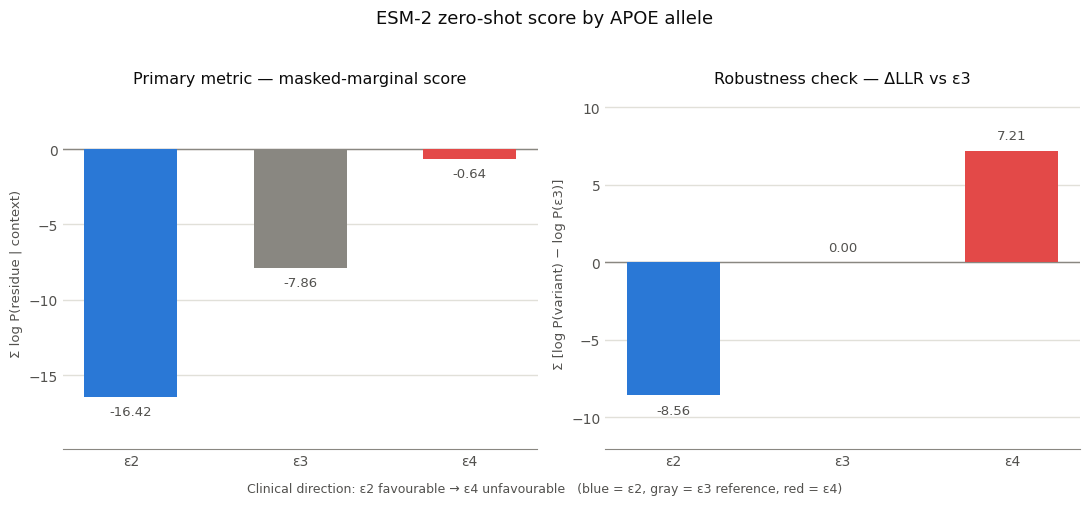

model ranking (best to worst):    ε4 > ε3 > ε2
clinical ranking (best to worst): ε2 > ε3 > ε4


In [10]:
PALETTE = {"APOE-e2": "#2a78d6", "APOE-e3": "#898781", "APOE-e4": "#e34948"}
INK_MUTED, INK_AXIS, GRID = "#52514e", "#898781", "#e1e0d9"

order = ["APOE-e2", "APOE-e3", "APOE-e4"]
labels = ["ε2", "ε3", "ε4"]
values = [df.set_index("variant").loc[n, "masked_marginal_total"] for n in order]
llrs   = [df.set_index("variant").loc[n, "delta_llr_vs_e3"] for n in order]
colors = [PALETTE[n] for n in order]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))

for ax, vals, title, ylab in [
    (axes[0], values, "Primary metric — masked-marginal score", "Σ log P(residue | context)"),
    (axes[1], llrs,   "Robustness check — ΔLLR vs ε3",          "Σ [log P(variant) − log P(ε3)]"),
]:
    bars = ax.bar(labels, vals, color=colors, width=0.55, edgecolor="none", zorder=3)
    ax.axhline(0, color=INK_AXIS, lw=1, zorder=2)
    ax.grid(axis="y", color=GRID, lw=1, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(INK_AXIS)
    ax.tick_params(colors=INK_MUTED, length=0)
    ax.set_title(title, fontsize=11.5, color="#0b0b0b", pad=10)
    ax.set_ylabel(ylab, fontsize=9.5, color=INK_MUTED)

    span = max(vals) - min(vals)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                v + (0.035 * span if v >= 0 else -0.035 * span),
                f"{v:.2f}", ha="center", va="bottom" if v >= 0 else "top",
                fontsize=9.5, color=INK_MUTED)
    ax.set_ylim(min(min(vals), 0) - 0.22 * span, max(max(vals), 0) + 0.22 * span)

fig.suptitle("ESM-2 zero-shot score by APOE allele", fontsize=13, color="#0b0b0b", y=1.03)
fig.text(0.5, -0.02,
         "Clinical direction: ε2 favourable → ε4 unfavourable   "
         "(blue = ε2, gray = ε3 reference, red = ε4)",
         ha="center", fontsize=9, color=INK_MUTED)
fig.tight_layout()
fig.savefig(RESULTS / "scores.png", dpi=160, bbox_inches="tight")
plt.show()

print("model ranking (best to worst):   ", " > ".join(
    df.sort_values('masked_marginal_total', ascending=False)['allele'].str.replace('e', 'ε')))
print("clinical ranking (best to worst): ε2 > ε3 > ε4")

In [11]:
model_order = list(df.sort_values("masked_marginal_total", ascending=False)["variant"])
clinical_order = sorted(CLINICAL_RANK, key=CLINICAL_RANK.get)

if model_order == clinical_order:
    VERDICT = "MATCH — model ranking reproduces the clinical direction"
elif model_order == clinical_order[::-1]:
    VERDICT = "NO MATCH — model ranking is exactly INVERTED relative to the clinical direction"
elif model_order[0] == clinical_order[0] or model_order[-1] == clinical_order[-1]:
    VERDICT = "PARTIAL MATCH — model ranking agrees at one end only"
else:
    VERDICT = "NO MATCH — model ranking does not correspond to the clinical direction"

print("VERDICT:", VERDICT)
print("  model    :", " > ".join(model_order))
print("  clinical :", " > ".join(clinical_order))
print("  both metrics agree on ordering:",
      list(df.sort_values("delta_llr_vs_e3", ascending=False)["variant"]) == model_order)

VERDICT: NO MATCH — model ranking is exactly INVERTED relative to the clinical direction
  model    : APOE-e4 > APOE-e3 > APOE-e2
  clinical : APOE-e2 > APOE-e3 > APOE-e4
  both metrics agree on ordering: True


## 6. Structure prediction with ESMFold

Each variant sequence is folded through the free ESM Metagenomic Atlas API ([PMID 36927031](https://pubmed.ncbi.nlm.nih.gov/36927031/)).
Three calls, no local GPU. pLDDT is ESMFold's own per-residue confidence estimate, rescaled here to the conventional
0–100 range; the usual rule of thumb is that pLDDT > 70 indicates a confidently predicted backbone.

**Read the confidence numbers before the structures.** As shown below, ESMFold's confidence on this target is low, and
that determines how much the structural comparison can be asked to support.

In [12]:
structures, confidence = {}, {}
for name, seq in variant_sequences.items():
    pdb_text = fold_sequence(seq)
    path = save_pdb(pdb_text, RESULTS / f"{name}.pdb")
    structures[name] = pdb_text
    confidence[name] = plddt_values(pdb_text)
    print(f"{name}: mean pLDDT = {mean_plddt(pdb_text):5.1f}   "
          f"residues with pLDDT > 70: {(confidence[name] > 70).mean():5.1%}   -> {path.name}")

CONFIDENT = np.where(np.all([confidence[n] > 70 for n in structures], axis=0))[0]
print(f"\nConfidently predicted in all three models: {len(CONFIDENT)} / {record.length} residues")

APOE-e2: mean pLDDT =  64.6   residues with pLDDT > 70: 19.9%   -> APOE-e2.pdb
APOE-e3: mean pLDDT =  63.6   residues with pLDDT > 70: 15.8%   -> APOE-e3.pdb


APOE-e4: mean pLDDT =  63.4   residues with pLDDT > 70: 18.6%   -> APOE-e4.pdb

Confidently predicted in all three models: 47 / 317 residues


ESMFold's confidence on APOE is **low**: mean pLDDT around 64, with only a small minority of residues above the
conventional 70 threshold. This is not surprising — APOE is a flexible, largely helical, two-domain lipid-binding
protein, and ESMFold predicts from a single sequence with no multiple sequence alignment
([PMID 36927031](https://pubmed.ncbi.nlm.nih.gov/36927031/)).

The consequence matters for interpretation: we compare the variants both globally and over the confidently predicted
core, and treat any difference as **prediction uncertainty unless it survives that restriction**.

In [13]:
reference_pdb = structures[REFERENCE]
aligned, deviations, rmsd_table = {REFERENCE: reference_pdb}, {}, []

for name, pdb_text in structures.items():
    if name == REFERENCE:
        continue
    global_pdb, global_rmsd, per_residue = superpose(pdb_text, reference_pdb)
    _, core_rmsd, _ = superpose(pdb_text, reference_pdb, subset=CONFIDENT)
    aligned[name] = global_pdb
    deviations[name] = per_residue
    rmsd_table.append({"comparison": f"{name} vs {REFERENCE}",
                       "global_ca_rmsd_A": round(global_rmsd, 2),
                       "confident_core_ca_rmsd_A": round(core_rmsd, 2)})

pd.DataFrame(rmsd_table)

,comparison,global_ca_rmsd_A,confident_core_ca_rmsd_A
0,APOE-e2 vs APOE-e3,10.39,0.91
1,APOE-e4 vs APOE-e3,6.10,1.26


C:\Users\aadit\AppData\Local\Temp\ipykernel_2244\1326774936.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


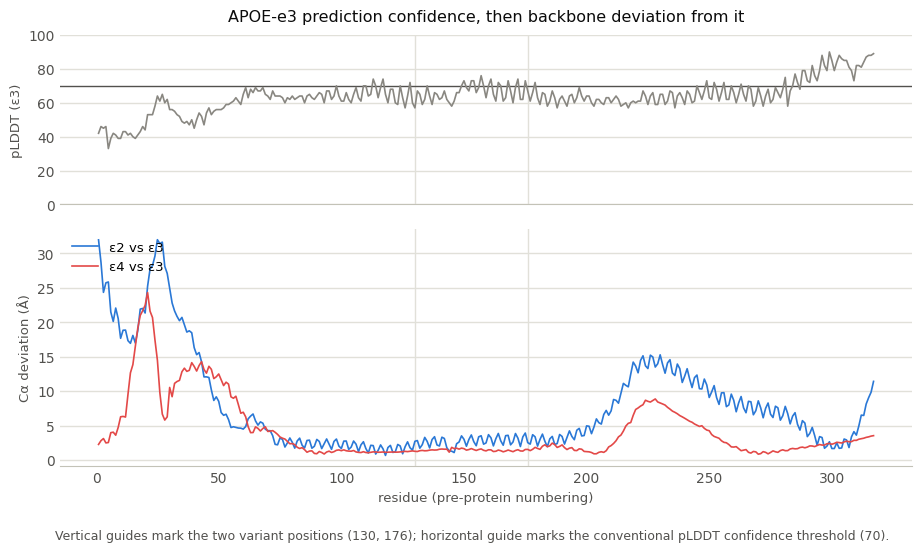

In [14]:
PALETTE2 = {"APOE-e2": "#2a78d6", "APOE-e4": "#e34948"}
CONF_COLOR = "#898781"

fig, (ax_conf, ax_dev) = plt.subplots(
    2, 1, figsize=(11, 5.6), sharex=True,
    gridspec_kw={"height_ratios": [1, 1.4], "hspace": 0.12},
)

x = range(1, record.length + 1)

# Top panel: single series (e3 confidence) -> no legend needed, title carries it.
ax_conf.plot(x, confidence[REFERENCE], lw=1.2, color=CONF_COLOR, zorder=3)
ax_conf.axhline(70, color=INK_MUTED, lw=1, zorder=2)
ax_conf.set_ylim(0, 100)
ax_conf.set_ylabel("pLDDT (ε3)", fontsize=9.5, color=INK_MUTED)
ax_conf.set_title(f"{REFERENCE} prediction confidence, then backbone deviation from it",
                   fontsize=11.5, color="#0b0b0b", pad=10)

# Bottom panel: two series -> legend.
for name in ("APOE-e2", "APOE-e4"):
    ax_dev.plot(range(1, len(deviations[name]) + 1), deviations[name],
                lw=1.2, color=PALETTE2[name], zorder=3,
                label=f"{name.replace('APOE-e', 'ε')} vs ε3")
ax_dev.set_ylabel("Cα deviation (Å)", fontsize=9.5, color=INK_MUTED)
ax_dev.set_xlabel("residue (pre-protein numbering)", fontsize=9.5, color=INK_MUTED)
ax_dev.legend(frameon=False, fontsize=9.5, loc="upper left")

for ax in (ax_conf, ax_dev):
    ax.grid(axis="y", color=GRID, lw=1, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color("#c3c2b7")
    ax.tick_params(colors=INK_MUTED, length=0)
    for position in POSITIONS:
        ax.axvline(position, color=GRID, lw=1, zorder=1)

fig.text(0.5, -0.02,
         f"Vertical guides mark the two variant positions ({POSITIONS[0]}, {POSITIONS[1]}); "
         "horizontal guide marks the conventional pLDDT confidence threshold (70).",
         ha="center", fontsize=9, color=INK_MUTED)
fig.tight_layout()
fig.savefig(RESULTS / "structure_deviation.png", dpi=160, bbox_inches="tight")
plt.show()

**No structural conclusion is drawn from this.** Globally the models differ by several ångströms, but that difference
collapses to roughly 1 Å when the fit is restricted to residues all three models predict confidently. The deviation
profile is near-zero across the whole central region containing both variant sites and rises only at the two ends —
the pattern expected from the domains being placed differently relative to one another, not from local structural
change at 130 or 176.

Note that pLDDT is a *local* confidence measure: the C-terminal segment is predicted with high pLDDT yet still shows
large deviation, precisely because local confidence says nothing about how that domain is positioned relative to the
rest of the protein. APOE is a flexible two-domain lipid-binding protein, so this is the expected failure mode.

Either way the confident core spans only 47 of 317 residues, so agreement there is weak evidence too: a single point
substitution cannot be separated from single-sequence prediction noise at this confidence level. The structures are
included for completeness and visual inspection. They are **not** evidence that the ε alleles do or do not differ in
fold, and the ranking reported above does not depend on them.

In [15]:
view = py3Dmol.view(width=860, height=560)
palette = {"APOE-e2": "#2a7fbf", "APOE-e3": "#8d8d8d", "APOE-e4": "#c0392b"}

for i, (name, pdb_text) in enumerate(aligned.items()):
    view.addModel(pdb_text, "pdb")
    view.setStyle({"model": i}, {"cartoon": {"color": palette[name], "opacity": 0.75}})
    # Highlight the two variable positions as sticks + spheres.
    view.addStyle({"model": i, "resi": POSITIONS},
                  {"stick": {"colorscheme": "greenCarbon", "radius": 0.28}})
    view.addStyle({"model": i, "resi": POSITIONS, "atom": "CA"},
                  {"sphere": {"color": palette[name], "radius": 1.1}})

for position in POSITIONS:
    view.addLabel(f"{position}",
                  {"fontSize": 13, "backgroundColor": "black", "backgroundOpacity": 0.6},
                  {"model": 1, "resi": position, "atom": "CA"})

view.zoomTo()
(RESULTS / "structure_overlay.html").write_text(view._make_html(), encoding="utf-8")
print("ε2 = blue, ε3 = grey, ε4 = red;  variable positions 130 and 176 shown as spheres/sticks")
view.show()

ε2 = blue, ε3 = grey, ε4 = red;  variable positions 130 and 176 shown as spheres/sticks


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

<a id="conclusion"></a>
## 7. Conclusion

**The hypothesis is not confirmed.** ESM-2's zero-shot ranking of the three APOE variants is
**ε4 > ε3 > ε2** — the exact reverse of the established clinical and longevity direction (ε2 favourable,
ε4 unfavourable; [PMID 30060062](https://pubmed.ncbi.nlm.nih.gov/30060062/),
[PMID 9343467](https://pubmed.ncbi.nlm.nih.gov/9343467/),
[PMID 26930295](https://pubmed.ncbi.nlm.nih.gov/26930295/)).

The result is not marginal or ambiguous:

- The ordering is **monotonically inverted**, not merely uncorrelated.
- **Both scoring formulations agree** — the per-variant masked marginal and the wild-type-context ΔLLR give the same
  ranking, so this is not an artefact of one scoring convention.
- The **margins are large**. With the site masked, ESM-2 assigns Arg — the ε4 residue at both positions — three to
  four orders of magnitude more probability than Cys. ε4 is Arg/Arg and therefore scores highest; ε2 is Cys/Cys and
  scores lowest.

The ranking rests entirely on the sequence scores. The structure predictions do **not** contribute to it: ESMFold's
confidence on APOE is low (mean pLDDT ≈ 64, few residues above the conventional 70 threshold), the differences between
the predicted models are concentrated at the termini and are consistent with uncertain inter-domain placement rather
than any local change at the variant sites, and a single point substitution is not separable from single-sequence
prediction noise at that confidence. No structural claim is made in either direction.

**What this does and does not show.** ESM-2's training objective is to predict residues from evolutionary sequence
context, so its scores measure how *typical* a residue is within the protein universe it was trained on. That is not
the same quantity as an effect on human healthspan or lifespan, and here the two point in opposite directions. A
residue can be evolutionarily unremarkable and still be associated with worse outcomes in modern humans — and, as
this experiment shows, the reverse as well. The practical conclusion is that **zero-shot protein-language-model
fitness scores should not be treated as a proxy for human longevity effects at this locus.** A single case study
cannot establish that this generalises to other loci, but it is a clear counterexample to the assumption.

**One hypothesis, explicitly flagged as outside this project's evidence base.** A natural explanation for the
inversion is that Arg at these positions is the residue favoured across the evolutionary sequence distribution the
model was trained on, so the model rewards it regardless of its consequences in humans. The citation set backing this
project ([§ References](#references)) does not cover APOE allele ancestry or cross-species conservation, so this is
recorded as an **untested hypothesis for follow-up, not a claim**. Testing it would require a separate analysis of
APOE orthologues, which is out of scope here.

A negative result is still a result: the question posed was specific and testable, and the answer is that this model
does not independently recover this association.

<a id="limitations"></a>
## 8. Limitations

- **The model has no aging or clinical signal.** ESM-2 and ESMFold were trained on general protein sequence and
  structure data, not on aging, mortality, or clinical-outcome data ([PMID 36927031](https://pubmed.ncbi.nlm.nih.gov/36927031/)).
  Any correspondence with clinical direction would have been a property of general sequence "naturalness", not a
  learned aging signal — and here there is no correspondence.
- **Fitness proxy ≠ disease risk.** Zero-shot mutation scores approximate evolutionary fitness / sequence
  plausibility, not Alzheimer's risk or lifespan. A match to the clinical direction would have been suggestive, not
  confirmatory of mechanism; a mismatch likewise does not overturn the clinical evidence, which rests on large human
  cohorts ([PMID 30060062](https://pubmed.ncbi.nlm.nih.gov/30060062/) — 28,297 participants across 7 cohorts).
- **Single-sequence structure prediction is less certain — and here it was not confident enough to use.** ESMFold
  predicts from one sequence without a multiple sequence alignment, which is faster but carries more uncertainty than
  MSA-based methods such as AlphaFold2 ([PMID 36927031](https://pubmed.ncbi.nlm.nih.gov/36927031/)). On APOE it
  returned a mean pLDDT of roughly 64, with only a small minority of residues above the conventional confidence
  threshold. The predicted structures are therefore reported for completeness and visual inspection only; they support
  no conclusion about whether the ε alleles differ in fold, and none is drawn.
- **n = 3.** One protein, three variants, one model. This is a single case study — not a benchmark, not a
  statistically powered test, and not a general claim about protein language models.
- **In silico only.** Nothing here is experimentally validated. Every number in this notebook is a model prediction
  and constitutes no biological finding beyond "this is what the model predicts."
- **APOE biology is not captured by point-substitution scoring.** These scores treat the protein as an isolated
  sequence; the ε2 allele's effects have been characterised at the level of lipid metabolism in carriers
  ([PMID 35997888](https://pubmed.ncbi.nlm.nih.gov/35997888/)), a level of biology entirely outside what a
  single-sequence model can represent.

<a id="references"></a>
## References

1. Farrer LA, Cupples LA, Haines JL, et al. Effects of age, sex, and ethnicity on the association between
   apolipoprotein E genotype and Alzheimer disease: a meta-analysis. *JAMA.* 1997;278(16):1349-1356.
   PMID: [9343467](https://pubmed.ncbi.nlm.nih.gov/9343467/).
2. Sebastiani P, Gurinovich A, Nygaard M, et al. APOE Alleles and Extreme Human Longevity.
   *J Gerontol A Biol Sci Med Sci.* 2019;74(1):44-51. doi:[10.1093/gerona/gly174](https://doi.org/10.1093/gerona/gly174).
   PMID: [30060062](https://pubmed.ncbi.nlm.nih.gov/30060062/).
3. Ryu S, Atzmon G, Barzilai N, Raghavachari N, Suh Y. Genetic landscape of APOE in human longevity revealed by
   high-throughput sequencing. *Mech Ageing Dev.* 2016;155:7-9.
   doi:[10.1016/j.mad.2016.02.010](https://doi.org/10.1016/j.mad.2016.02.010).
   PMID: [26930295](https://pubmed.ncbi.nlm.nih.gov/26930295/).
4. Sebastiani P, Song Z, Ellis D, et al. A metabolomic signature of the APOE2 allele. *GeroScience.*
   2022;45(1):415-426. doi:[10.1007/s11357-022-00646-9](https://doi.org/10.1007/s11357-022-00646-9).
   PMID: [35997888](https://pubmed.ncbi.nlm.nih.gov/35997888/).
5. Lin Z, Akin H, Rao R, et al. Evolutionary-scale prediction of atomic-level protein structure with a language
   model. *Science.* 2023;379(6637):1123-1130. doi:[10.1126/science.ade2574](https://doi.org/10.1126/science.ade2574).
   PMID: [36927031](https://pubmed.ncbi.nlm.nih.gov/36927031/).

*All citations retrieved from PubMed on 2026-07-25.*

**Data sources.** UniProt accession [P02649](https://www.uniprot.org/uniprotkb/P02649) (sequence);
NCBI dbSNP [rs429358](https://www.ncbi.nlm.nih.gov/snp/rs429358) and
[rs7412](https://www.ncbi.nlm.nih.gov/snp/rs7412) (numbering verification). Both retrieved programmatically at run
time — see the timestamps printed above and in `data/variants.json`.